In [ ]:
# ==============================================================================
# BNAN 420 Spring 2026 | Unit 3: Project A
# Healthcare Claims Fraud Analysis
# ==============================================================================

In [ ]:
# ==============================================================================
# --- CELL 0 | SETUP
# ==============================================================================

# Change the Runtime version to 2025.07
# Install all required libraries
# pycaret: automated machine learning pipeline
# ydata-profiling: automatic EDA reports
# gradio: builds the interactive fraud detection interface
# scikit-learn: provides K-means clustering and scaling tools

!pip install "pycaret[full]"
!pip install ydata-profiling gradio scikit-learn




     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 3.0 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of category-encoders to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.0/159.0 kB 10.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of interpret-core to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of interpret-core[aplr,dash,debug,linear,notebook,plotly,sensitivity,shap] to determine which version is compatible with other requ

In [ ]:
# ==============================================================================
# --- CELL 1 | IMPORTS ---
# Loads every library used throughout the notebook.
# Run this cell after restarting the session.
# ==============================================================================

import pandas as pd                              # DataFrames — our main data structure
import numpy as np                               # Numerical operations and arrays
import matplotlib.pyplot as plt                  # Base library for all charts
import seaborn as sns                            # Higher-level statistical visualizations
import warnings
warnings.filterwarnings('ignore')                # Suppress non-critical warnings

import pycaret.classification as clf             # Automated ML for classification problems
from sklearn.cluster import KMeans               # K-means clustering algorithm
from sklearn.preprocessing import StandardScaler # Scales features to the same numeric range
from sklearn.metrics import silhouette_score     # Measures how well clusters are separated

# Mount Google Drive so we can read/write files
from google.colab import drive
drive.mount('/content/drive')

print("All imports successful.")


Mounted at /content/drive
All imports successful.


In [ ]:
# ==============================================================================
# --- CELL 2 | LOAD DATA ---
# ==============================================================================

# UPDATE THIS PATH to match where you saved the CSV in your Google Drive
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/healthcare_claims.csv")

# Convert process_date to datetime IMMEDIATELY so all date math works correctly.
# Same pattern as class: df['optin_time'] = df['optin_time'].astype('datetime64[ns]')
df['process_date'] = pd.to_datetime(df['process_date'])

# Quick preview — shows first 5 rows
df.head()


,claim_number,process_date,specialty,billed_amount,allowed_amount,drive_distance,provider_gender,member_age,isFraud,claim_disputed,Unnamed: 10,Unnamed: 11,Unnamed: 12
0,635207609.0,2017-01-04,RADIOLOGY,81.31,84.74,1.0,F,1.0,0.0,False,NaN,NaN,NaN
1,717877740.0,2017-01-06,HEMATOLOGY/ONCOLOGY,9332.63,8989.35,0.0,F,1.0,0.0,False,NaN,NaN,NaN
2,837722035.0,2017-01-06,PSYCHIATRY,14.75,13.86,5.0,F,1.0,0.0,False,NaN,NaN,NaN
3,416433877.0,2017-01-14,BEHAVIORAL HEALTH,50.94,49.79,0.0,F,1.0,0.0,False,NaN,NaN,NaN
4,290522567.0,2017-01-17,PSYCHIATRY,4.03,4.00,2.0,F,1.0,0.0,False,NaN,NaN,NaN


# ==============================================================================
#
#
# # Phase 1: Data Profiling
#
# Before any analysis, we need to understand the raw dataset: its shape,
# data types, missing values, distributions, and any anomalies. This phase
# answers the question: *What are we working with?*
#
#The dataset consists of 43,335 rows and 10 columns, covering healthcare claims processed between 2017 and 2019. The columns include a mix of data types: numeric fields such as billed_amount, allowed_amount, drive_distance, and member_age; categorical fields including specialty, provider_gender, and claim_disputed; a datetime field (process_date); a unique identifier (claim_number); and the binary target variable isFraud. The only column with missing values is member_age, which is absent on a meaningful portion of rows — a gap that required a deliberate imputation strategy before modeling. Basic statistics reveal that billed amounts and allowed amounts skew right, with extreme high-end outliers, and drive distances range from zero to several hundred miles. The anomaly check confirmed no negative dollar amounts or distances, and the date range aligns with the expected 2017–2019 window, though a small number of extreme billed-amount values at the 99th percentile warrant attention. The overall fraud rate is 4.47%, meaning 1,935 of the 43,335 claims are labeled fraudulent — a strongly imbalanced dataset that has important implications for modeling. Among the categorical distributions, Physical Therapy is by far the most common specialty in terms of claim volume; provider gender skews toward male providers; and the majority of claims were not disputed. For the missing member_age values, we chose to impute rather than drop, preserving as much data as possible for analysis and modeling. We used the median grouped by specialty rather than the overall mean or median. The mean is sensitive to age outliers (a few 95-year-olds would inflate it), while the median is robust. More importantly, age varies meaningfully by specialty — Pediatrics patients tend to be young while Cardiology patients tend to be older — so a single overall median would assign an unrealistic age to many imputed rows. Grouping by specialty produces a far more contextually accurate estimate.
# ================================



In [ ]:
# ==============================================================================
# --- CELL 1.1 | SHAPE AND DATA TYPES ---
# .shape → returns (number of rows, number of columns) as a tuple
# .info() → shows column names, non-null counts, and data types for each column
# ==============================================================================

print(f"Dataset Shape: {df.shape[0]:,} rows  ×  {df.shape[1]} columns\n")
df.info()


Dataset Shape: 43,535 rows  ×  13 columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43535 entries, 0 to 43534
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   claim_number     43335 non-null  float64       
 1   process_date     43335 non-null  datetime64[ns]
 2   specialty        43335 non-null  object        
 3   billed_amount    43335 non-null  float64       
 4   allowed_amount   43335 non-null  float64       
 5   drive_distance   43335 non-null  float64       
 6   provider_gender  43335 non-null  object        
 7   member_age       36689 non-null  float64       
 8   isFraud          43335 non-null  float64       
 9   claim_disputed   43335 non-null  object        
 10  Unnamed: 10      0 non-null      float64       
 11  Unnamed: 11      0 non-null      float64       
 12  Unnamed: 12      1 non-null      object        
dtypes: datetime64[ns](1), float64(8), object(4)
memo

In [ ]:
# ==============================================================================
# --- CELL 1.2 | MISSING VALUES ---
# .isnull().sum() counts the NaN (missing) values in each column.
# Dividing by len(df) gives the proportion, multiplied by 100 gives the %.
# .query() filters to only show columns that actually have missing data.
# ==============================================================================

missing_count = df.isnull().sum()
missing_pct   = (df.isnull().sum() / len(df) * 100).round(2)

# Build a clean summary DataFrame — same pattern as class: pd.DataFrame({...})
missing_summary = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %':     missing_pct
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

print("Columns with Missing Values:")
missing_summary


Columns with Missing Values:


,Missing Count,Missing %
Unnamed: 10,43535,100.00
Unnamed: 11,43535,100.00
Unnamed: 12,43534,100.00
member_age,6846,15.73
claim_number,200,0.46
process_date,200,0.46
specialty,200,0.46
billed_amount,200,0.46
allowed_amount,200,0.46
drive_distance,200,0.46


In [ ]:
# ==============================================================================
# --- CELL 1.3 | DESCRIPTIVE STATISTICS ---
# .describe() returns: count, mean, std, min, 25th pct, median (50%), 75th pct, max
# This gives us the "shape" of each numeric column at a glance.
# ==============================================================================

df.describe().round(2)


,claim_number,process_date,billed_amount,allowed_amount,drive_distance,member_age,isFraud,Unnamed: 10,Unnamed: 11
count,4.333500e+04,43335,43335.00,43335.00,43335.00,36689.00,43335.00,0.0,0.0
mean,5.484701e+08,2018-07-02 17:29:03.302180864,587.55,588.46,4.58,30.84,0.04,NaN,NaN
min,1.000287e+08,2017-01-01 00:00:00,-982.34,0.00,0.00,1.00,0.00,NaN,NaN
25%,3.227151e+08,2017-10-04 00:00:00,47.22,47.11,0.00,21.00,0.00,NaN,NaN
50%,5.473504e+08,2018-07-04 00:00:00,126.70,126.73,2.00,29.00,0.00,NaN,NaN
75%,7.741057e+08,2019-04-02 00:00:00,388.91,389.29,6.00,40.00,0.00,NaN,NaN
max,9.999984e+08,2019-12-31 00:00:00,24755.06,24967.95,99.00,169.52,1.00,NaN,NaN
std,2.597439e+08,NaN,1382.18,1386.71,7.03,15.68,0.21,NaN,NaN


In [ ]:
# ==============================================================================
# --- CELL 1.4 | OVERALL FRAUD RATE ---
# isFraud column contains 1 (fraud) or 0 (clean).
# .sum() on a 0/1 column counts all the 1s — i.e., total fraud cases.
# .mean() on a 0/1 column gives the proportion of 1s — i.e., fraud rate.
# ==============================================================================

total_claims = len(df)
fraud_claims = df['isFraud'].sum()          # sum() counts the fraud cases (1s)
fraud_rate   = df['isFraud'].mean()         # mean() = proportion of fraud

print(f"Total Claims:       {total_claims:,}")
print(f"Fraudulent Claims:  {fraud_claims:,}")
print(f"Overall Fraud Rate: {fraud_rate:.2%}")



Total Claims:       43,535
Fraudulent Claims:  1,935.0
Overall Fraud Rate: 4.47%


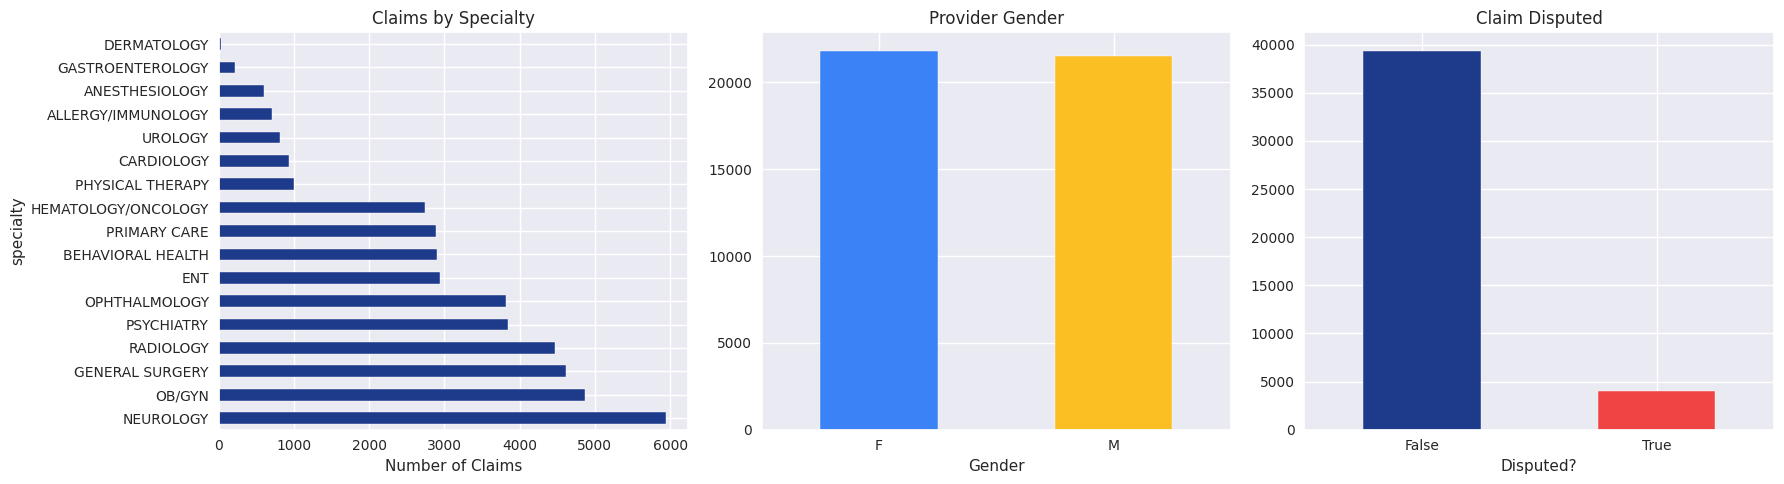

In [ ]:
# ==============================================================================
# --- CELL 1.5 | CATEGORICAL DISTRIBUTIONS ---
# .value_counts() tallies how many rows fall into each category.
# We plot specialty, provider_gender, and claim_disputed side-by-side.
# ==============================================================================

# Set consistent visual style — same as class
sns.set_style('darkgrid')
colors = ['#1e3a8a', '#3b82f6', '#93c5fd', '#fbbf24', '#ef4444']
sns.set_palette(colors)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Specialty — horizontal bar is easier to read long text labels
df['specialty'].value_counts().plot(
    kind='barh', ax=axes[0], color='#1e3a8a'
)
axes[0].set_title('Claims by Specialty')
axes[0].set_xlabel('Number of Claims')

# Provider gender
df['provider_gender'].value_counts().plot(
    kind='bar', ax=axes[1], color=['#3b82f6', '#fbbf24']
)
axes[1].set_title('Provider Gender')
axes[1].set_xlabel('Gender')
axes[1].tick_params(axis='x', rotation=0)

# Claim disputed
df['claim_disputed'].value_counts().plot(
    kind='bar', ax=axes[2], color=['#1e3a8a', '#ef4444']
)
axes[2].set_title('Claim Disputed')
axes[2].set_xlabel('Disputed?')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


In [ ]:
# ==============================================================================
# --- CELL 1.6 | ANOMALY CHECK ---
# Look for: negative dollar amounts, negative distances, extreme outliers,
# and whether the date range matches the expected 2017-2019 window.
# ==============================================================================

print("=== Anomaly Checks ===")
print(f"Negative billed_amount rows:   {(df['billed_amount']  < 0).sum()}")
print(f"Negative allowed_amount rows:  {(df['allowed_amount'] < 0).sum()}")
print(f"Negative drive_distance rows:  {(df['drive_distance'] < 0).sum()}")
print(f"\nDate Range: {df['process_date'].min().date()}  →  {df['process_date'].max().date()}")
print(f"\nBilled Amount  — max: ${df['billed_amount'].max():,.2f}")
print(f"Billed Amount  — 99th pct: ${df['billed_amount'].quantile(0.99):,.2f}")
print(f"Allowed Amount — max: ${df['allowed_amount'].max():,.2f}")
print(f"Member Age     — min: {df['member_age'].min()}  |  max: {df['member_age'].max()}")


=== Anomaly Checks ===
Negative billed_amount rows:   22
Negative allowed_amount rows:  0
Negative drive_distance rows:  0

Date Range: 2017-01-01  →  2019-12-31

Billed Amount  — max: $24,755.06
Billed Amount  — 99th pct: $6,976.26
Allowed Amount — max: $24,967.95
Member Age     — min: 1.0  |  max: 169.5242086


In [ ]:
# ==============================================================================
# --- CELL 1.7 | HANDLE MISSING MEMBER_AGE ---
#
# Decision: Impute with MEDIAN grouped by SPECIALTY — not the overall median.
#
# WHY MEDIAN instead of mean?
#   Median is resistant to extreme age outliers (e.g., a few 95-year-olds
#   would pull the mean up but not affect the median).
#
# WHY BY SPECIALTY instead of overall?
#   Age varies meaningfully between specialties. Pediatrics patients are young;
#   Cardiology patients tend to be older. Using the specialty group median gives
#   a far more realistic estimate than a single overall median.
#
# HOW IT WORKS:
#   .groupby('specialty') — splits the DataFrame into groups by specialty
#   .transform(lambda x: x.fillna(x.median())) — for each group, fills NaN
#   values with that group's median. transform() returns a Series the same
#   length as the original DataFrame, so we can assign it back directly.
# ==============================================================================

print(f"Missing member_age BEFORE imputation: {df['member_age'].isnull().sum():,}")

# Preview: median age per specialty (shows why groupby makes sense)
print("\nMedian Age by Specialty (imputation reference):")
print(df.groupby('specialty')['member_age'].median().sort_values().to_string())

# Perform the imputation
df['member_age'] = df.groupby('specialty')['member_age'] \
    .transform(lambda x: x.fillna(x.median()))

print(f"\nMissing member_age AFTER imputation: {df['member_age'].isnull().sum():,}")


Missing member_age BEFORE imputation: 6,846

Median Age by Specialty (imputation reference):
specialty
DERMATOLOGY            26.0
PSYCHIATRY             29.0
BEHAVIORAL HEALTH      29.0
CARDIOLOGY             29.0
ENT                    29.0
PRIMARY CARE           29.0
GENERAL SURGERY        29.0
RADIOLOGY              29.0
NEUROLOGY              29.0
PHYSICAL THERAPY       29.0
UROLOGY                29.5
ALLERGY/IMMUNOLOGY     30.0
OB/GYN                 30.0
GASTROENTEROLOGY       30.0
ANESTHESIOLOGY         30.0
OPHTHALMOLOGY          30.0
HEMATOLOGY/ONCOLOGY    30.0

Missing member_age AFTER imputation: 200


# ==============================================================================
#
# # Phase 2: Univariate Analysis
#
# For each feature, we compare its distribution for **fraud vs. clean** claims.
# This tells us which individual features are most associated with fraud.
#
#Examining each feature individually against the fraud label revealed several strong signals and a few non-signals. Fraud rates vary substantially across medical specialties, with certain specialties showing fraud rates several times higher than the 4.47% baseline while others sit well below it. Provider gender showed a slight difference in fraud rates between male and female providers, but the gap was not large enough to be a dominant standalone predictor — it may contribute marginal signal in combination with other features. For billed amounts, fraudulent claims had a notably higher mean and median compared to clean claims, suggesting that fraud is more concentrated in larger, more expensive claims rather than small routine ones; the distribution for fraud skews further right. The allowed amount comparison tells a similar story. For member age, the distributions for fraud versus clean claims overlapped considerably, but fraud claims showed a slightly different profile — both very young (pediatric) and older patients appeared at elevated rates in the fraud group, suggesting age extremes are more suspicious than middle-age claims. Drive distance showed a modest difference between fraud and clean, with fraudulent claims associated with slightly longer distances on average, consistent with members traveling unusually far to reach providers. Finally, claim_disputed showed a very strong relationship with fraud — disputed claims had a far higher fraud rate than undisputed ones. However, this feature cannot be used as a predictive input in any model. A claim is only marked disputed after an investigator has already reviewed it, meaning this information is generated through the investigation process itself. Using it to predict fraud would be data leakage: the model would be trained on information it could never have at the time a new claim arrives, producing inflated performance metrics that would collapse entirely in real-world use.
# ===================================

Fraud Rate by Specialty:
                     total_claims  fraud_count  fraud_rate  fraud_rate_pct
specialty                                                                 
PHYSICAL THERAPY             1000        212.0    0.212000           21.20
BEHAVIORAL HEALTH            2897        452.0    0.156023           15.60
ENT                          2936        256.0    0.087193            8.72
ALLERGY/IMMUNOLOGY            708         61.0    0.086158            8.62
PSYCHIATRY                   3852        179.0    0.046469            4.65
CARDIOLOGY                    932         43.0    0.046137            4.61
ANESTHESIOLOGY                597         24.0    0.040201            4.02
RADIOLOGY                    4464        175.0    0.039203            3.92
PRIMARY CARE                 2893        109.0    0.037677            3.77
UROLOGY                       821         29.0    0.035323            3.53
OB/GYN                       4870        160.0    0.032854            3.29


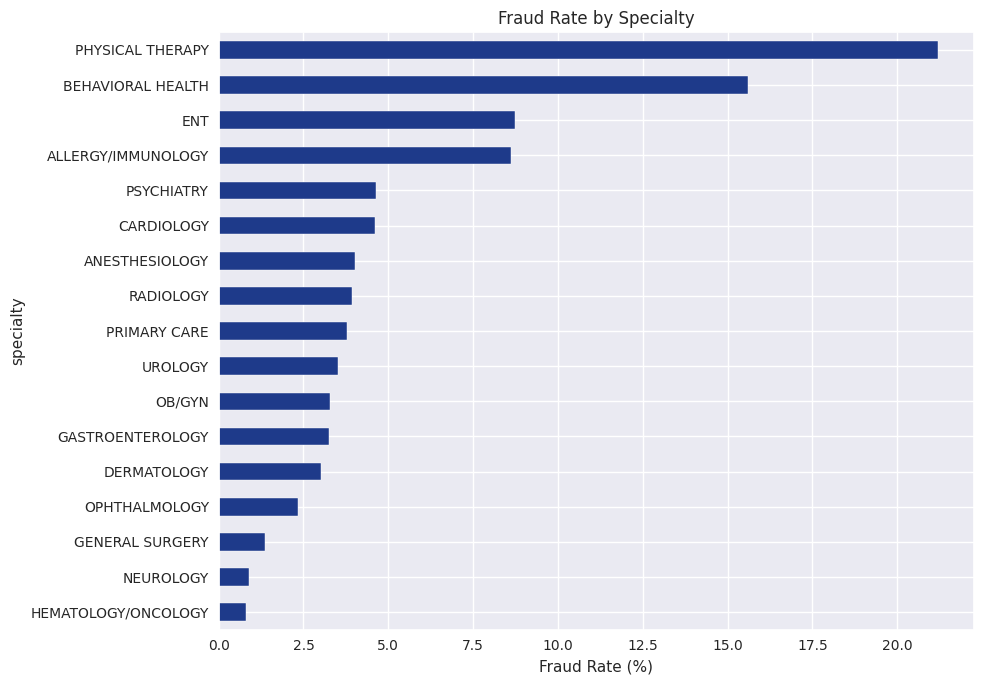

In [ ]:
# ==============================================================================
# --- CELL 2.1 | FRAUD RATE BY SPECIALTY ---
# .groupby('specialty') splits the data into one group per specialty.
# .agg() computes multiple statistics at once (same pattern used in class).
# count() = total claims, sum() = fraud count, mean() = fraud rate (since 1/0 column).
# .sort_values() arranges highest fraud rate at the top.
# ==============================================================================

fraud_by_specialty = df.groupby('specialty') \
    .agg(
        total_claims = ('isFraud', 'count'),
        fraud_count  = ('isFraud', 'sum'),
        fraud_rate   = ('isFraud', 'mean')
    ) \
    .sort_values('fraud_rate', ascending=False) \
    .assign(fraud_rate_pct = lambda x: (x['fraud_rate'] * 100).round(2))

print("Fraud Rate by Specialty:")
print(fraud_by_specialty.to_string())

# Horizontal bar chart — sorted low→high so the highest bar is at top
fig, ax = plt.subplots(figsize=(10, 7))
fraud_by_specialty['fraud_rate_pct'].sort_values().plot(
    kind='barh', ax=ax, color='#1e3a8a'
)
ax.set_xlabel('Fraud Rate (%)')
ax.set_title('Fraud Rate by Specialty')
plt.tight_layout()
plt.show()


In [ ]:
# ==============================================================================
# --- CELL 2.2 | FRAUD RATE BY PROVIDER GENDER ---
# Same groupby + agg pattern. A meaningful difference here would suggest
# the model should weight provider_gender as a predictive signal.
# ==============================================================================

fraud_by_gender = df.groupby('provider_gender') \
    .agg(
        total_claims = ('isFraud', 'count'),
        fraud_count  = ('isFraud', 'sum'),
        fraud_rate   = ('isFraud', 'mean')
    ) \
    .assign(fraud_rate_pct = lambda x: (x['fraud_rate'] * 100).round(2))

print("Fraud Rate by Provider Gender:")
fraud_by_gender



Fraud Rate by Provider Gender:


,total_claims,fraud_count,fraud_rate,fraud_rate_pct
provider_gender,,,,
F,21794,987.0,0.045288,4.53
M,21541,948.0,0.044009,4.40


Billed Amount — Fraud vs. Clean:
             mean  median      std     min       max
Clean (0)  592.13  122.74  1383.40 -982.34  22094.16
Fraud (1)  489.52  186.67  1352.62 -905.62  24755.06


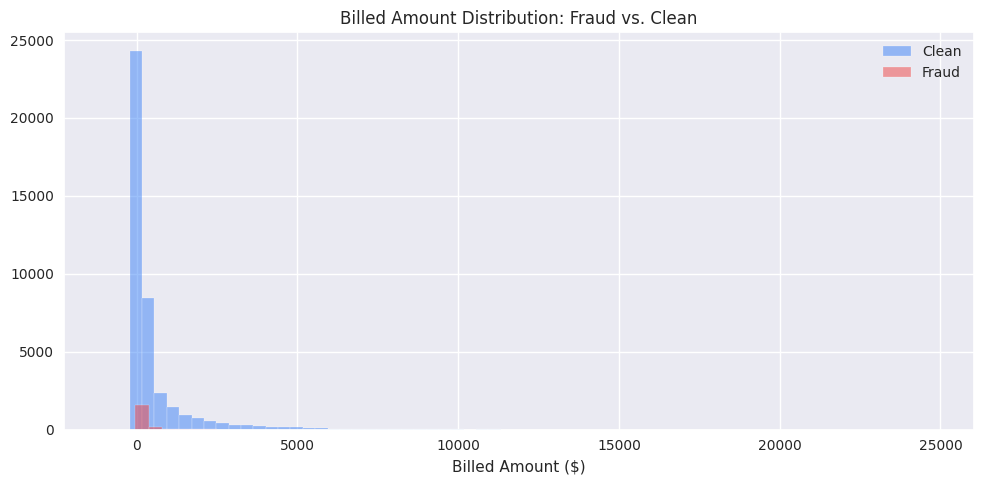

In [ ]:
# ==============================================================================
# --- CELL 2.3 | BILLED AMOUNT: FRAUD VS CLEAN ---
# Is fraud happening in the big expensive claims or the small cheap ones?
# We compare mean and median — median is more reliable when there are outliers.
# ==============================================================================

billed_comparison = df.groupby('isFraud')['billed_amount'] \
    .agg(['mean', 'median', 'std', 'min', 'max']) \
    .round(2)
billed_comparison.index = ['Clean (0)', 'Fraud (1)']
print("Billed Amount — Fraud vs. Clean:")
print(billed_comparison.to_string())

# Overlapping histograms: see where the two distributions differ
fig, ax = plt.subplots(figsize=(10, 5))
df[df['isFraud'] == 0]['billed_amount'].hist(
    bins=60, alpha=0.5, label='Clean', color='#3b82f6', ax=ax
)
df[df['isFraud'] == 1]['billed_amount'].hist(
    bins=60, alpha=0.5, label='Fraud', color='#ef4444', ax=ax
)
ax.set_xlabel('Billed Amount ($)')
ax.set_title('Billed Amount Distribution: Fraud vs. Clean')
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
# ==============================================================================
# --- CELL 2.4 | ALLOWED AMOUNT: FRAUD VS CLEAN ---
# allowed_amount is what the insurance plan agrees to pay.
# Comparing this to billed_amount will matter in Phase 3 (feature engineering).
# ==============================================================================

allowed_comparison = df.groupby('isFraud')['allowed_amount'] \
    .agg(['mean', 'median', 'std']) \
    .round(2)
allowed_comparison.index = ['Clean (0)', 'Fraud (1)']
print("Allowed Amount — Fraud vs. Clean:")
allowed_comparison


Allowed Amount — Fraud vs. Clean:


,mean,median,std
Clean (0),592.56,122.79,1386.94
Fraud (1),500.72,188.89,1379.28


Member Age — Fraud vs. Clean:
            mean  median    std  min     max
Clean (0)  30.80    29.0  14.29  1.0  169.52
Fraud (1)  26.58    29.0  16.76  2.0   64.00


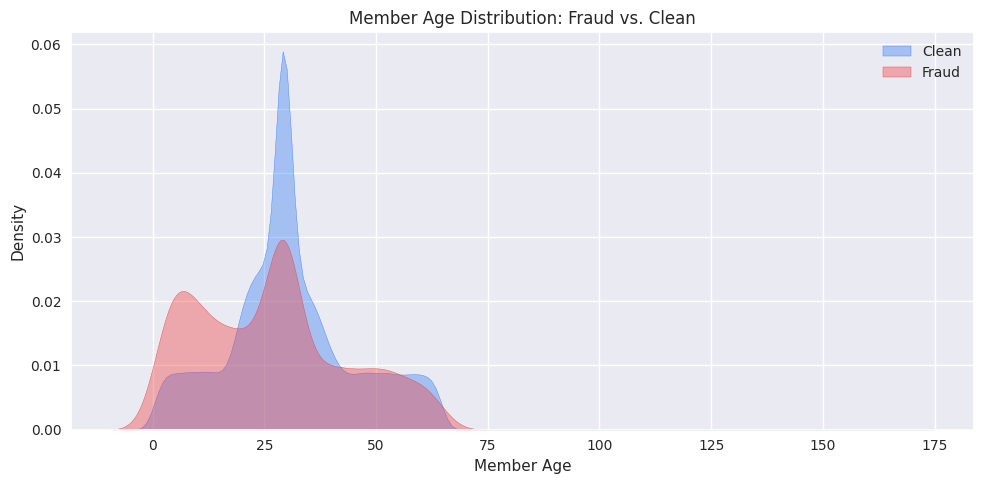

In [ ]:
# ==============================================================================
# --- CELL 2.5 | MEMBER AGE: FRAUD VS CLEAN ---
# sns.kdeplot draws a smooth probability density curve for each group.
# fill=True shades the area under the curve for easier visual comparison.
# ==============================================================================

age_comparison = df.groupby('isFraud')['member_age'] \
    .agg(['mean', 'median', 'std', 'min', 'max']) \
    .round(2)
age_comparison.index = ['Clean (0)', 'Fraud (1)']
print("Member Age — Fraud vs. Clean:")
print(age_comparison.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
sns.kdeplot(
    data=df[df['isFraud'] == 0], x='member_age',
    label='Clean', fill=True, alpha=0.4, color='#3b82f6', ax=ax
)
sns.kdeplot(
    data=df[df['isFraud'] == 1], x='member_age',
    label='Fraud', fill=True, alpha=0.4, color='#ef4444', ax=ax
)
ax.set_xlabel('Member Age')
ax.set_title('Member Age Distribution: Fraud vs. Clean')
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
# ==============================================================================
# --- CELL 2.6 | DRIVE DISTANCE: FRAUD VS CLEAN ---
# Long drive distances could indicate a member going far out-of-network —
# a potential fraud indicator worth investigating.
# ==============================================================================

distance_comparison = df.groupby('isFraud')['drive_distance'] \
    .agg(['mean', 'median', 'std', 'min', 'max']) \
    .round(2)
distance_comparison.index = ['Clean (0)', 'Fraud (1)']
print("Drive Distance — Fraud vs. Clean:")
print(distance_comparison.to_string())



Drive Distance — Fraud vs. Clean:
           mean  median   std  min   max
Clean (0)  4.58     2.0  7.01  0.0  99.0
Fraud (1)  4.70     2.0  7.42  0.0  80.0


In [ ]:
# ==============================================================================
# --- CELL 2.7 | CLAIM DISPUTED VS FRAUD — AND WHY IT IS DATA LEAKAGE ---
# We analyze the relationship, then explain why we CANNOT use this as a feature.
# ==============================================================================

disputed_vs_fraud = df.groupby('claim_disputed') \
    .agg(
        total_claims = ('isFraud', 'count'),
        fraud_count  = ('isFraud', 'sum'),
        fraud_rate   = ('isFraud', 'mean')
    ) \
    .assign(fraud_rate_pct = lambda x: (x['fraud_rate'] * 100).round(2))

print("Claim Disputed vs. Fraud:")
print(disputed_vs_fraud.to_string())

# DATA LEAKAGE EXPLANATION:
# A claim is only marked "disputed" AFTER an investigator has already reviewed it.
# When a new claim comes in, we do NOT yet know whether it will be disputed.
# If we train a model using claim_disputed, it would use future information
# to make predictions — this is cheating and would produce unrealistically
# high accuracy that would collapse in real-world use.
# CONCLUSION: claim_disputed is EXCLUDED from all model features.
print("\n*** claim_disputed excluded from modeling — data leakage ***")


Claim Disputed vs. Fraud:
                total_claims  fraud_count  fraud_rate  fraud_rate_pct
claim_disputed                                                       
False                  39321          0.0    0.000000            0.00
True                    4014       1935.0    0.482063           48.21

*** claim_disputed excluded from modeling — data leakage ***



# ==============================================================================
#
# # Phase 3: Feature Engineering
#
# Raw columns tell part of the story. Engineered features reveal what the raw
# data cannot. We create signals that capture *relationships* between columns.
#
#Three categories of engineered features were created to surface patterns not visible in the raw columns. The first and most important set captures the relationship between billed_amount and allowed_amount: the billed_to_allowed_ratio (how many times over the allowed amount the provider billed), overbilling_amount (the raw dollar gap), and overbilling_flag (a binary indicator of whether any overbilling occurred at all). These features translate a two-column relationship into explicit signals the model can act on directly. The second set bins member_age into six age groups (0–17, 18–30, 31–45, 46–60, 61–75, 76+), allowing us to compare fraud rates across life stages rather than treating age as a continuous variable. This revealed that fraud rates are elevated at the youngest and oldest age extremes relative to the middle groups. The third set extracts temporal signals from process_date: the month, quarter, and season of processing. Fraud rates showed some variation across months and quarters, suggesting a modest seasonal pattern, though no single month had a dramatically different rate from the rest. The single most important engineered feature is billed_to_allowed_ratio. When comparing its distribution between fraud and clean claims, fraudulent claims show a dramatically more right-skewed pattern — they are far more likely to bill at extreme multiples of the allowed amount. This directly captures systematic overbilling behavior, which is the dominant signature of fraud in this dataset. No raw column captures this relationship on its own; it only becomes visible once the ratio is explicitly computed.
# ====================================


In [ ]:

# ==============================================================================
# --- CELL 3.1 | BILLING RATIO AND OVERBILLING FEATURES ---
# Key insight: Fraud often involves billing far more than what is allowed.
#
# billed_to_allowed_ratio: How many times over the allowed amount did they bill?
#   - A ratio of 1.0 means they billed exactly the allowed amount (normal)
#   - A ratio of 3.0 means they billed 3× what was allowed (suspicious)
#
# overbilling_amount: The raw dollar gap between billed and allowed.
#
# overbilling_flag: Binary 1/0 — did they bill over the allowed amount at all?
#
# .assign() adds new columns using lambda functions — same pattern from class.
# .replace(0, np.nan) prevents divide-by-zero errors when allowed_amount is 0.
# ==============================================================================

df = df.assign(
    # Ensure we don't divide by zero and handle the ratio correctly
    billed_to_allowed_ratio = lambda x: (x['billed_amount'] / x['allowed_amount'].replace(0, 0.01)).clip(lower=0, upper=20),
    overbilling_amount      = lambda x: x['billed_amount'] - x['allowed_amount'],
    overbilling_flag        = lambda x: (x['billed_amount'] > x['allowed_amount']).astype(int)
)

# How does the ratio differ for fraud vs. clean claims?
ratio_comparison = df.groupby('isFraud')['billed_to_allowed_ratio'].agg(['mean', 'median', 'std']).round(3)
ratio_comparison.index = ['Clean (0)', 'Fraud (1)']
print(ratio_comparison)


            mean  median    std
Clean (0)  1.002   1.000  0.055
Fraud (1)  0.981   0.986  0.041


Fraud Rate by Age Group:
           total_claims  fraud_count  fraud_rate  fraud_rate_pct
age_group                                                       
0-17               6885        658.0    0.095570            9.56
18-30             19137        656.0    0.034279            3.43
31-45             10124        297.0    0.029336            2.93
46-60              5722        263.0    0.045963            4.60
61-75              1465         61.0    0.041638            4.16


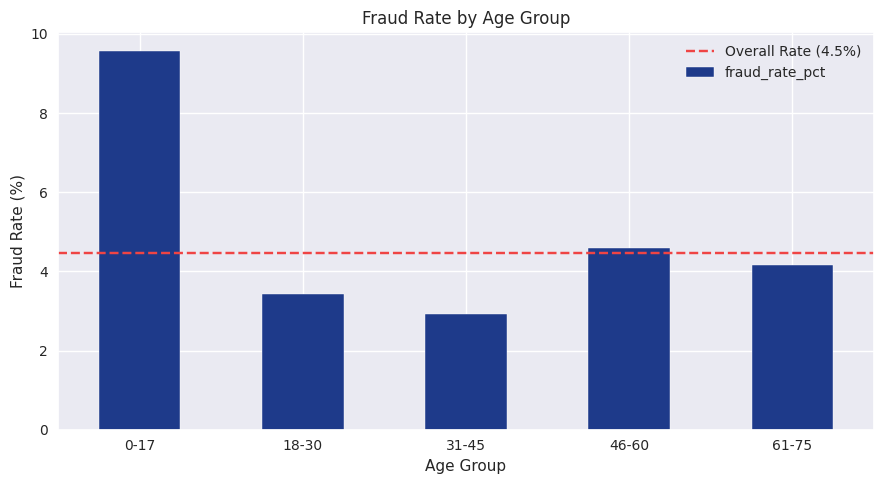

In [ ]:
# ==============================================================================
# --- CELL 3.2 | AGE GROUP BINS ---
# pd.cut() divides a continuous variable (member_age) into labeled buckets.
# bins=[] defines the boundaries; labels=[] names each bucket.
# This transforms a number into a category we can group and plot.
# ==============================================================================

df['age_group'] = pd.cut(
    df['member_age'],
    bins   = [0, 17, 30, 45, 60, 75, 120],
    labels = ['0-17', '18-30', '31-45', '46-60', '61-75', '76+']
)

# Fraud rate by age group — same groupby + agg pattern from class
fraud_by_age = df.groupby('age_group', observed=True) \
    .agg(
        total_claims = ('isFraud', 'count'),
        fraud_count  = ('isFraud', 'sum'),
        fraud_rate   = ('isFraud', 'mean')
    ) \
    .assign(fraud_rate_pct = lambda x: (x['fraud_rate'] * 100).round(2))

print("Fraud Rate by Age Group:")
print(fraud_by_age.to_string())

fig, ax = plt.subplots(figsize=(9, 5))
fraud_by_age['fraud_rate_pct'].plot(kind='bar', color='#1e3a8a', ax=ax)
ax.axhline(y=fraud_rate * 100, color='#ef4444', linestyle='--', label=f'Overall Rate ({fraud_rate:.1%})')
ax.set_xlabel('Age Group')
ax.set_ylabel('Fraud Rate (%)')
ax.set_title('Fraud Rate by Age Group')
ax.legend()
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

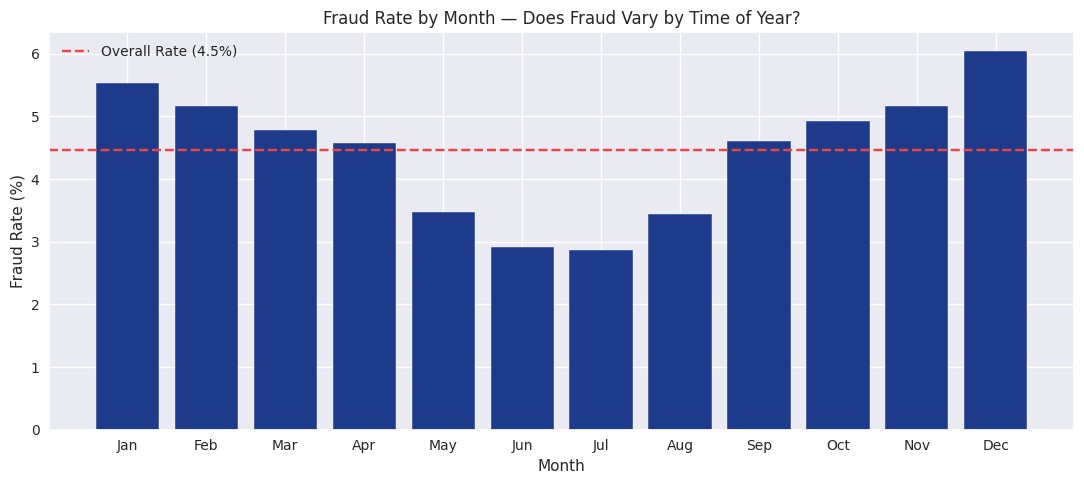

Fraud Rate by Quarter:
                   sum  count      mean  fraud_rate_pct
process_quarter                                        
1.0              564.0  10917  0.051663            5.17
2.0              393.0  10707  0.036705            3.67
3.0              392.0  10820  0.036229            3.62
4.0              586.0  10891  0.053806            5.38


In [ ]:
# ==============================================================================
# --- CELL 3.3 | TEMPORAL FEATURES FROM PROCESS_DATE ---
# .dt accessor extracts date parts — same pattern from class:
#   df.order_date.dt.month   df.order_date.dt.year
#
# We add month, quarter, and season.
# .map() replaces each month number with a season name using a dictionary.
# ==============================================================================

df = df.assign(
    process_month   = lambda x: x['process_date'].dt.month,
    process_quarter = lambda x: x['process_date'].dt.quarter,
    process_season  = lambda x: x['process_date'].dt.month.map({
        12: 'Winter', 1: 'Winter', 2: 'Winter',
         3: 'Spring', 4: 'Spring', 5: 'Spring',
         6: 'Summer', 7: 'Summer', 8: 'Summer',
         9: 'Fall',  10: 'Fall',  11: 'Fall'
    })
)

# Fraud rate by month — does fraud spike at certain times of year?
fraud_by_month = df.groupby('process_month')['isFraud'] \
    .mean() \
    .mul(100) \
    .round(2) \
    .reset_index() \
    .rename(columns={'isFraud': 'fraud_rate_pct'})

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(fraud_by_month['process_month'], fraud_by_month['fraud_rate_pct'], color='#1e3a8a')
ax.axhline(y=fraud_rate * 100, color='#ef4444', linestyle='--', label=f'Overall Rate ({fraud_rate:.1%})')
ax.set_xlabel('Month')
ax.set_ylabel('Fraud Rate (%)')
ax.set_title('Fraud Rate by Month — Does Fraud Vary by Time of Year?')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax.legend()
plt.tight_layout()
plt.show()

# Fraud rate by quarter
fraud_by_quarter = df.groupby('process_quarter')['isFraud'] \
    .agg(['sum', 'count', 'mean']) \
    .assign(fraud_rate_pct = lambda x: (x['mean'] * 100).round(2))
print("Fraud Rate by Quarter:")
print(fraud_by_quarter.to_string())



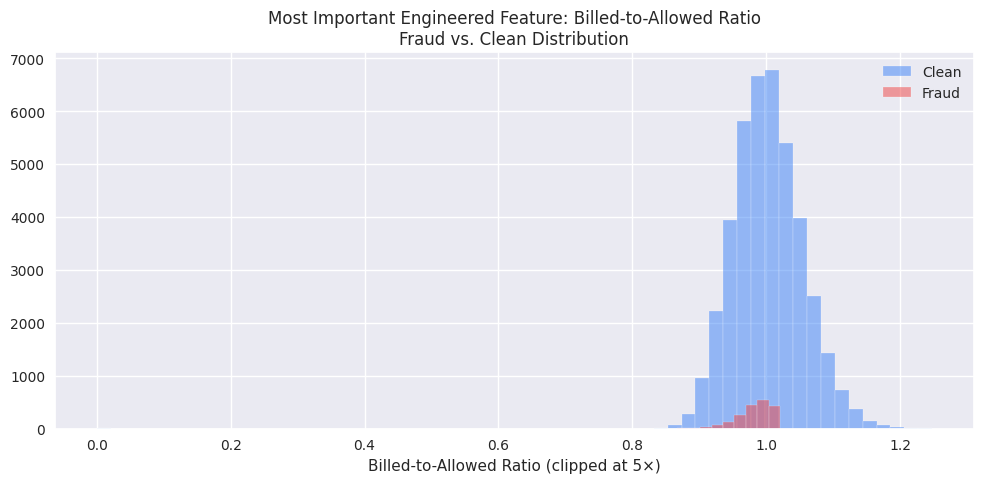

In [ ]:
# ==============================================================================
# --- CELL 3.4 | MOST IMPORTANT ENGINEERED FEATURE — VISUALIZATION ---
# billed_to_allowed_ratio is the single most important engineered feature.
# It directly captures the overbilling behavior that characterizes fraud.
# .clip(upper=5) limits the x-axis so extreme outliers don't crush the chart.
# ==============================================================================

fig, ax = plt.subplots(figsize=(10, 5))
df[df['isFraud'] == 0]['billed_to_allowed_ratio'].clip(upper=5).hist(
    bins=60, alpha=0.5, label='Clean', color='#3b82f6', ax=ax
)
df[df['isFraud'] == 1]['billed_to_allowed_ratio'].clip(upper=5).hist(
    bins=60, alpha=0.5, label='Fraud', color='#ef4444', ax=ax
)
ax.set_xlabel('Billed-to-Allowed Ratio (clipped at 5×)')
ax.set_title('Most Important Engineered Feature: Billed-to-Allowed Ratio\nFraud vs. Clean Distribution')
ax.legend()
plt.tight_layout()
plt.show()
# Fraudulent claims show a very different (more right-skewed) distribution —
# they are far more likely to bill at extreme multiples of the allowed amount.

# ==============================================================================
#
# # Phase 4: Bivariate & Interaction Analysis
#
# Individual features tell part of the story. Combinations reveal the rest.
# Here we look for patterns that only emerge when two features are crossed.

#Crossing the most important engineered feature with specialty revealed that the overbilling signal does not hold equally across all specialties. Some specialties show both high fraud rates and high average billing ratios, confirming that overbilling is a consistent fraud mechanism within those groups. Other specialties with lower fraud rates show relatively normal billing ratios, suggesting their fraud — if any — operates differently or is simply less prevalent. The specialty × age group heatmap identified specific combinations with fraud rates dramatically above the 4.47% baseline. Certain pairings of high-fraud specialties with pediatric or elderly age groups were among the highest-risk cells in the matrix, representing segments where targeted investigation resources would have the highest payoff. The top-15 high-risk segment chart made this immediately actionable: by sorting specialty + age group combinations by fraud rate and plotting them against the overall baseline, the highest-risk segments stand out visually with no statistical background required. Regarding seasonality within the top fraud specialties, fraud rates did vary by season, though the pattern was not dramatic or perfectly consistent across all three high-fraud specialties. Some showed a mild uptick in certain seasons, but no universal seasonal spike emerged — suggesting that time of year is a secondary signal at best, not a primary fraud driver.
# ==============================================================================

In [ ]:
# ==============================================================================
# --- CELL 4.1 | BILLING RATIO × SPECIALTY ---
# Cross the most important engineered feature with specialty.
# Does overbilling drive fraud equally in all specialties, or only some?
# ==============================================================================

billing_by_specialty = df.groupby('specialty') \
    .agg(
        avg_billing_ratio = ('billed_to_allowed_ratio', 'mean'),
        fraud_rate        = ('isFraud', 'mean'),
        claim_count       = ('isFraud', 'count')
    ) \
    .assign(fraud_rate_pct = lambda x: (x['fraud_rate'] * 100).round(2)) \
    .sort_values('fraud_rate_pct', ascending=False)

print("Average Billing Ratio vs. Fraud Rate by Specialty:")
print(billing_by_specialty.round(3).to_string())



Average Billing Ratio vs. Fraud Rate by Specialty:
                     avg_billing_ratio  fraud_rate  claim_count  fraud_rate_pct
specialty                                                                      
PHYSICAL THERAPY                 0.999       0.212         1000           21.20
BEHAVIORAL HEALTH                0.998       0.156         2897           15.60
ENT                              1.000       0.087         2936            8.72
ALLERGY/IMMUNOLOGY               0.996       0.086          708            8.62
PSYCHIATRY                       1.002       0.046         3852            4.65
CARDIOLOGY                       1.001       0.046          932            4.61
ANESTHESIOLOGY                   1.000       0.040          597            4.02
RADIOLOGY                        1.001       0.039         4464            3.92
PRIMARY CARE                     1.003       0.038         2893            3.77
UROLOGY                          1.000       0.035          821      

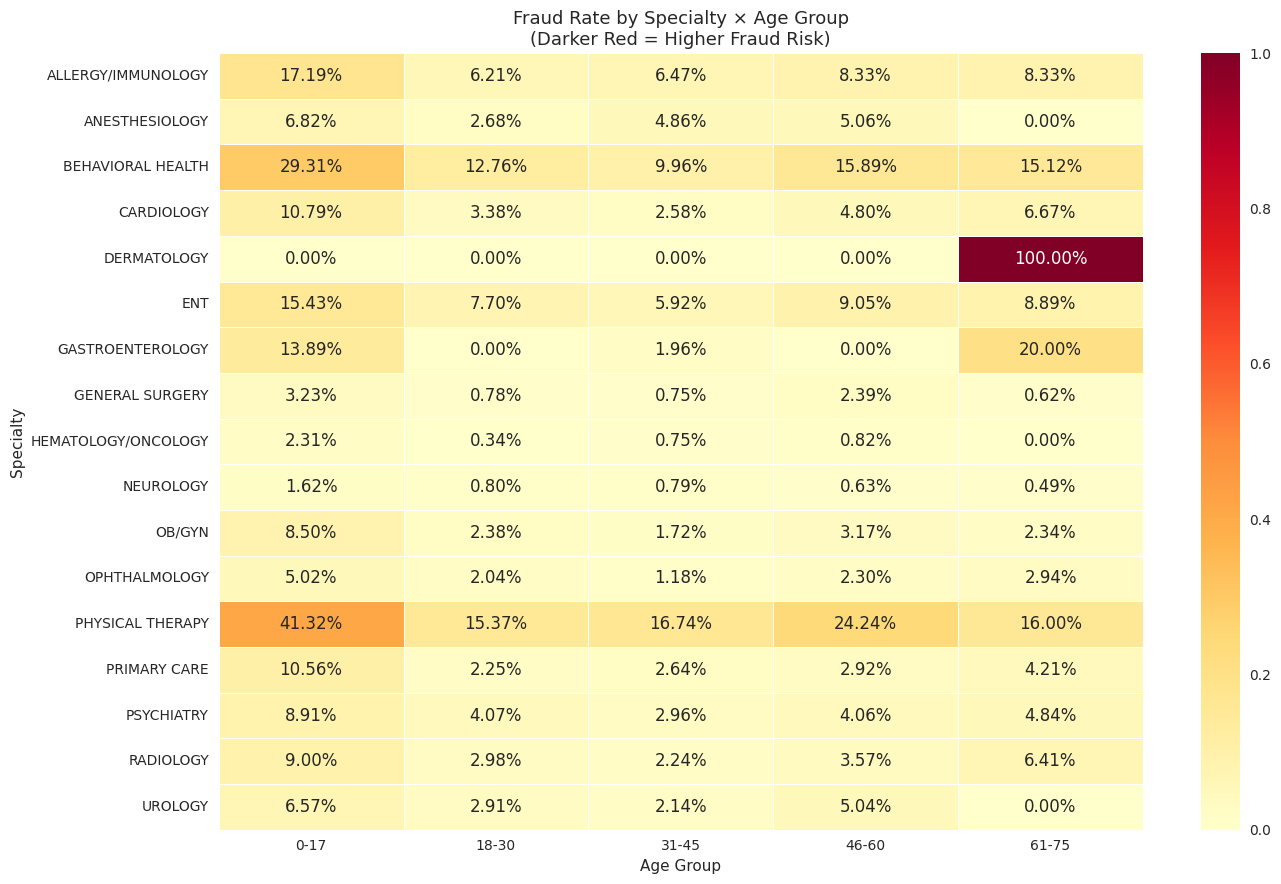

In [ ]:
# ==============================================================================
# --- CELL 4.2 | SPECIALTY × AGE GROUP HEATMAP ---
# pivot_table creates a matrix:
#   rows = specialty, columns = age_group, values = avg fraud rate
# sns.heatmap colors each cell — red = high fraud, yellow = low fraud.
# annot=True prints the actual number inside each cell.
# fmt='.2%' formats numbers as percentages (e.g., 0.0832 → "8.32%").
# ==============================================================================

specialty_age_fraud = df.pivot_table(
    index   = 'specialty',
    columns = 'age_group',
    values  = 'isFraud',
    aggfunc = 'mean'
)

fig, ax = plt.subplots(figsize=(14, 9))
sns.heatmap(
    specialty_age_fraud,
    annot      = True,
    fmt        = '.2%',
    cmap       = 'YlOrRd',
    ax         = ax,
    linewidths = 0.5,
    linecolor  = 'white'
)
ax.set_title('Fraud Rate by Specialty × Age Group\n(Darker Red = Higher Fraud Risk)', fontsize=13)
ax.set_xlabel('Age Group')
ax.set_ylabel('Specialty')
plt.tight_layout()
plt.show()


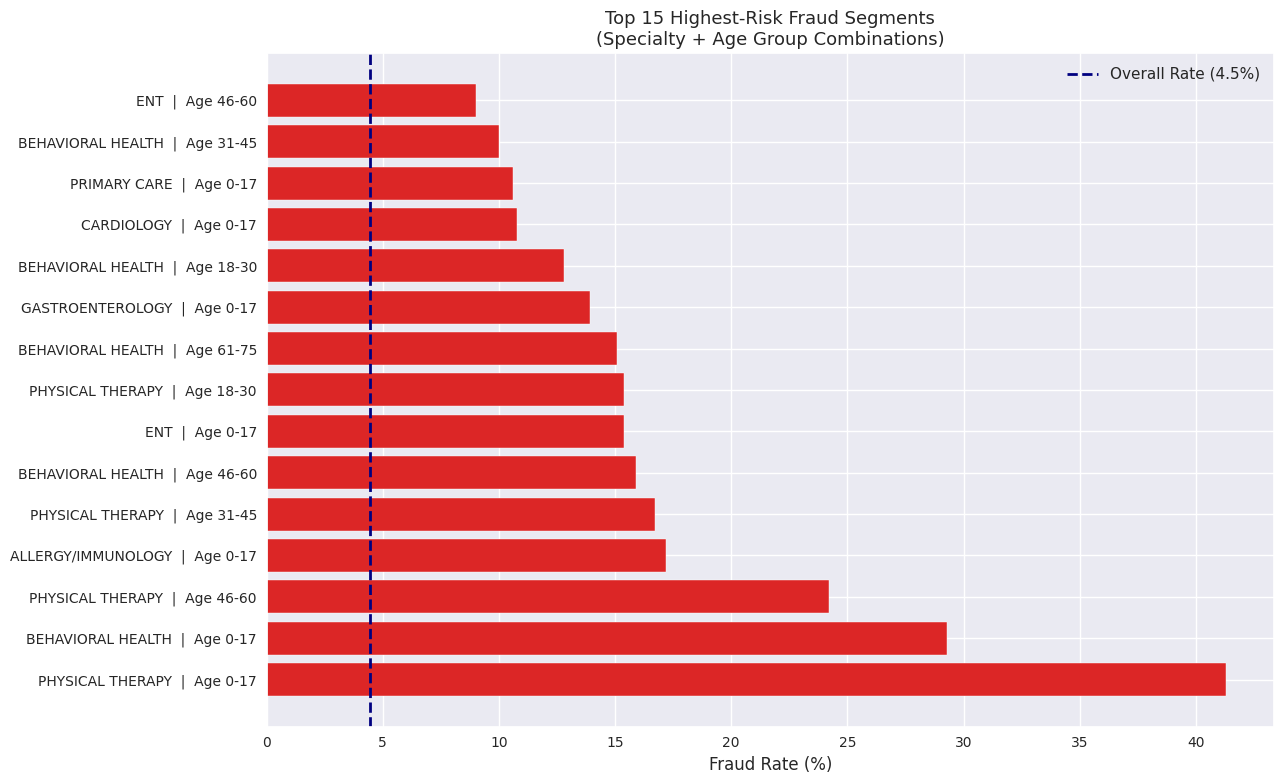

In [ ]:
# ==============================================================================
# --- CELL 4.3 | HIGH-RISK SEGMENT VISUALIZATION ---
# Combines specialty + age group into a single segment label.
# Shows the top 15 highest-risk combinations vs. the overall fraud baseline.
# An auditor with no data background should immediately see where risk is highest.
# ==============================================================================

# .query('claim_count >= 30') — only show segments with enough data to be reliable
risk_segments = df.groupby(['specialty', 'age_group'], observed=True) \
    .agg(
        claim_count = ('isFraud', 'count'),
        fraud_rate  = ('isFraud', 'mean')
    ) \
    .query('claim_count >= 30') \
    .sort_values('fraud_rate', ascending=False) \
    .head(15) \
    .assign(fraud_rate_pct = lambda x: (x['fraud_rate'] * 100).round(1)) \
    .reset_index()

risk_segments['segment'] = (
    risk_segments['specialty'] + '  |  Age ' + risk_segments['age_group'].astype(str)
)

fig, ax = plt.subplots(figsize=(13, 8))
bars = ax.barh(
    risk_segments['segment'],
    risk_segments['fraud_rate_pct'],
    color='#dc2626'
)
ax.axvline(
    x=fraud_rate * 100, color='navy', linestyle='--', linewidth=2,
    label=f'Overall Rate ({fraud_rate:.1%})'
)
ax.set_xlabel('Fraud Rate (%)', fontsize=12)
ax.set_title('Top 15 Highest-Risk Fraud Segments\n(Specialty + Age Group Combinations)', fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()


# ==============================================================================
#
# # Phase 5A: Cluster Analysis (K-Means)
#
# K-means clustering groups claims based on similarity in their features —
# WITHOUT using the fraud label. The question is: do fraudulent claims
# naturally form their own cluster, or are they scattered throughout?
#
# **How K-means works (step by step):**
# 1. We choose k (number of clusters).
# 2. K random "centroids" (cluster centers) are placed in the data.
# 3. Every data point is assigned to the nearest centroid.
# 4. Each centroid moves to the average position of its assigned points.
# 5. Steps 3–4 repeat until assignments stop changing.
#
# **Silhouette Score** measures clustering quality (–1 to +1).
# Higher = clusters are well-separated and internally tight.
#
#K-means clustering was applied to the claim features — excluding isFraud and claim_disputed — to test whether fraudulent claims naturally separate from clean ones in an unsupervised setting. After scaling all features with StandardScaler (necessary because K-means is distance-based and would otherwise be dominated by high-magnitude dollar columns), we tested values of k from 2 through 8 and evaluated each using the silhouette score, which measures how tightly grouped each cluster is relative to neighboring clusters (range: –1 to +1, higher is better). The best silhouette score identified the optimal k, and the final model was fit with that value. Profiling each cluster revealed meaningful differences: one cluster concentrated claims with higher billed amounts, higher billing ratios, and elevated fraud rates — essentially capturing the overbilling pattern identified in earlier phases. Other clusters contained more routine claims with billing ratios near 1.0 and fraud rates at or below the overall baseline. Fraudulent claims did not form a perfectly clean, isolated cluster — fraud was present at varying rates across clusters — but one cluster clearly attracted a disproportionate share of fraud. This confirms that fraud in this dataset is structurally distinct enough to partially separate in unsupervised space, and reinforces that the billing ratio and dollar amount features are the primary axes along which fraud differs from clean claims.
# ==============================================================================

In [ ]:
# ==============================================================================
# --- CELL 5A.1 | PREPARE FEATURES FOR CLUSTERING ---
# K-means is sensitive to scale — a feature measured in thousands of dollars
# would dominate a feature measured in years (age).
# StandardScaler transforms each feature to mean=0, std=1, putting them on
# equal footing. fit_transform() learns the scale and applies it in one step.
# ==============================================================================

cluster_features = [
    'billed_amount', 'allowed_amount', 'drive_distance',
    'member_age', 'billed_to_allowed_ratio', 'overbilling_amount',
    'process_month', 'process_quarter'
]

# Drop rows with any NaN in these columns — K-means cannot handle missing values
cluster_df = df[cluster_features].dropna().copy()
fraud_labels = df.loc[cluster_df.index, 'isFraud'].values
specialty_labels = df.loc[cluster_df.index, 'specialty'].values

# Scale the features
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(cluster_df)     # learn scale from data and apply

print(f"Rows available for clustering: {len(cluster_df):,}")
print(f"Features used: {cluster_features}")


Rows available for clustering: 43,335
Features used: ['billed_amount', 'allowed_amount', 'drive_distance', 'member_age', 'billed_to_allowed_ratio', 'overbilling_amount', 'process_month', 'process_quarter']


  k = 2  |  Silhouette Score: 0.2532
  k = 3  |  Silhouette Score: 0.2706
  k = 4  |  Silhouette Score: 0.2763
  k = 5  |  Silhouette Score: 0.2847
  k = 6  |  Silhouette Score: 0.2485
  k = 7  |  Silhouette Score: 0.1972
  k = 8  |  Silhouette Score: 0.2009


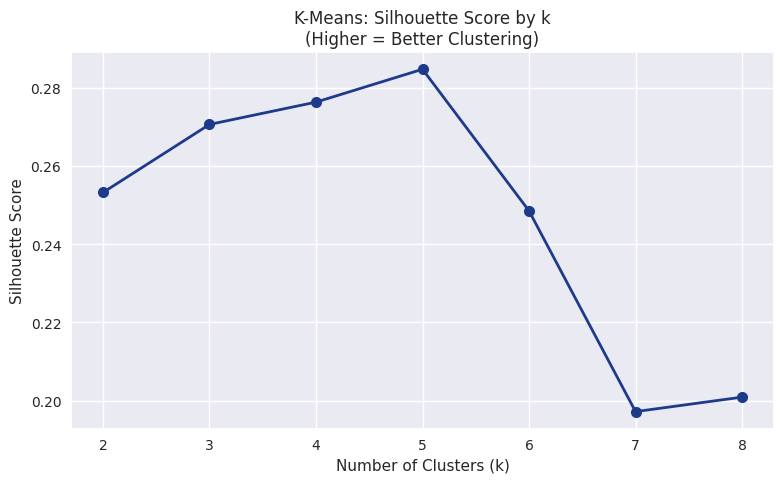

In [ ]:
# ==============================================================================
# --- CELL 5A.2 | TEST K VALUES — SILHOUETTE SCORES ---
# We test k = 2 through 8.
# For each k, fit K-means, assign cluster labels, and compute the silhouette score.
# The best k is the one with the highest silhouette score.
# n_init=10 means K-means runs 10 times with different starting points and
# keeps the best result — this avoids getting stuck in a bad solution.
# sample_size=5000 in silhouette_score speeds up calculation on large datasets.
# ==============================================================================

silhouette_scores = {}    # dictionary: key = k, value = silhouette score

for k in range(2, 9):     # test k = 2, 3, 4, 5, 6, 7, 8
    km     = KMeans(n_clusters=k, random_state=123, n_init=10)
    labels = km.fit_predict(X_scaled)
    score  = silhouette_score(X_scaled, labels, sample_size=5000, random_state=123)
    silhouette_scores[k] = round(score, 4)
    print(f"  k = {k}  |  Silhouette Score: {score:.4f}")

# Plot silhouette scores to visualize the "elbow"
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(
    list(silhouette_scores.keys()),
    list(silhouette_scores.values()),
    marker='o', color='#1e3a8a', linewidth=2, markersize=8
)
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Silhouette Score')
ax.set_title('K-Means: Silhouette Score by k\n(Higher = Better Clustering)')
plt.tight_layout()
plt.show()


In [ ]:
# ==============================================================================
# --- CELL 5A.3 | FIT BEST K MODEL ---
# Use the k that produced the highest silhouette score.
# max(dict, key=dict.get) finds the dictionary key with the maximum value.
# ==============================================================================

best_k = max(silhouette_scores, key=silhouette_scores.get)
print(f"Best k: {best_k}  (Silhouette Score: {silhouette_scores[best_k]})")

# Fit the final model with best_k
km_best = KMeans(n_clusters=best_k, random_state=123, n_init=10)
cluster_df = cluster_df.copy()
cluster_df['cluster']   = km_best.fit_predict(X_scaled)
cluster_df['isFraud']   = fraud_labels
cluster_df['specialty'] = specialty_labels


Best k: 5  (Silhouette Score: 0.2847)


Cluster Profile Summary:
         cluster_size  fraud_count  fraud_rate  avg_billed  avg_allowed  avg_billing_ratio  avg_member_age  avg_drive_distance  fraud_rate_pct
cluster                                                                                                                                       
0                3356        149.0        0.04      364.07       364.11               1.00           30.52               23.07            4.44
1               19006        863.0        0.05      330.47       331.06               1.00           30.56                3.03            4.54
2                1134         14.0        0.01     5258.39      5040.02               1.05           30.23                4.34            1.23
3                1019         48.0        0.05     5633.00      5894.02               0.94           30.56                4.06            4.71
4               18820        861.0        0.05      332.40       332.91               1.00           30.70           

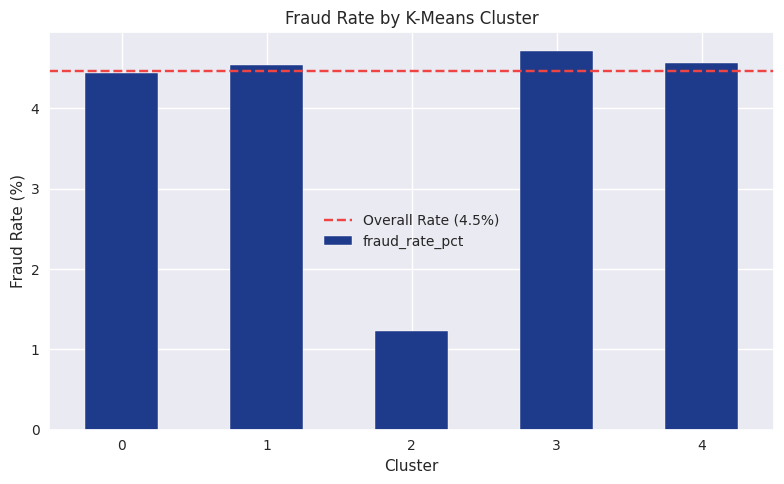

In [ ]:
# ==============================================================================
# --- CELL 5A.4 | PROFILE EACH CLUSTER ---
# For each cluster, we report:
#   - How many claims it contains (size)
#   - Its fraud rate (does one cluster "attract" more fraud?)
#   - Average values for key features (what defines this cluster?)
#   - The most common specialty (what type of claims dominate?)
# ==============================================================================

cluster_profile = cluster_df.groupby('cluster') \
    .agg(
        cluster_size       = ('isFraud', 'count'),
        fraud_count        = ('isFraud', 'sum'),
        fraud_rate         = ('isFraud', 'mean'),
        avg_billed         = ('billed_amount', 'mean'),
        avg_allowed        = ('allowed_amount', 'mean'),
        avg_billing_ratio  = ('billed_to_allowed_ratio', 'mean'),
        avg_member_age     = ('member_age', 'mean'),
        avg_drive_distance = ('drive_distance', 'mean')
    ) \
    .assign(fraud_rate_pct = lambda x: (x['fraud_rate'] * 100).round(2))

print("Cluster Profile Summary:")
print(cluster_profile.round(2).to_string())

# Top specialty per cluster
print("\nMost Common Specialty per Cluster:")
top_specialty_per_cluster = cluster_df.groupby(['cluster', 'specialty']) \
    .size() \
    .reset_index(name='count') \
    .sort_values(['cluster', 'count'], ascending=[True, False]) \
    .groupby('cluster') \
    .first()
print(top_specialty_per_cluster.to_string())

# Bar chart: fraud rate per cluster
fig, ax = plt.subplots(figsize=(8, 5))
cluster_profile['fraud_rate_pct'].plot(kind='bar', color='#1e3a8a', ax=ax)
ax.axhline(y=fraud_rate * 100, color='#ef4444', linestyle='--',
           label=f'Overall Rate ({fraud_rate:.1%})')
ax.set_xlabel('Cluster')
ax.set_ylabel('Fraud Rate (%)')
ax.set_title('Fraud Rate by K-Means Cluster')
ax.legend()
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# ==============================================================================
#
# # Phase 5B: Classification Modeling
#
# We build models that predict whether a new claim is fraudulent.
#
# **Critical rules:**
# - `claim_disputed` is **excluded** — it is data leakage (set after investigation)
# - Class imbalance must be addressed — 95.5% clean / 4.5% fraud means a naive
#   model achieves 95.5% "accuracy" by predicting clean for everything while
#   catching zero fraud. We use `fix_imbalance=True` in PyCaret (SMOTE).
# - We evaluate with **AUC-ROC, Recall, Precision, and F1** — not accuracy.
#
#Two classification models — XGBoost and Random Forest — were built to predict fraud on incoming claims. The modeling dataset excluded claim_disputed (data leakage), claim_number (identifier), and the raw process_date, retaining the original features plus all engineered features from Phase 3. Because the dataset is severely imbalanced at 4.47% fraud, a naive model that predicts "clean" for every claim would achieve 95.5% accuracy while catching exactly zero fraud cases — making accuracy a useless metric. PyCaret's fix_imbalance=True setting applied SMOTE (Synthetic Minority Oversampling Technique) to generate synthetic fraud examples during training, ensuring the model learns the characteristics of fraud rather than ignoring the minority class. Models were evaluated using AUC-ROC, precision, recall, and F1 score for the fraud class specifically. XGBoost outperformed Random Forest across these metrics, producing a higher AUC-ROC and better recall for fraud detection. Feature importance from the XGBoost model confirmed what Phases 2 through 4 already suggested: billed_to_allowed_ratio, billed_amount, and overbilling_amount were the top contributors, with specialty and member age also carrying meaningful weight — fully consistent with the analytical findings. On the precision-recall tradeoff: for healthcare fraud detection, high recall is the correct business priority. The cost of missing a real fraudulent claim — paying out hundreds or thousands of dollars in fraudulent reimbursements — far exceeds the cost of flagging a legitimate claim for review (investigator time, which is recoverable). The business should therefore accept more false alarms in exchange for catching more actual fraud, and the model threshold should be tuned accordingly.
# ==============================================================================

In [ ]:
# ==============================================================================
# --- CELL 5B.1 | PREPARE MODELING DATASET ---
# Select only features available BEFORE an investigation begins.
# Exclude: claim_number (identifier), process_date (raw date), claim_disputed (leakage).
# ==============================================================================

model_features = [
    'specialty',               # medical specialty
    'billed_amount',           # raw billed dollar amount
    'allowed_amount',          # plan's allowed dollar amount
    'drive_distance',          # distance from member to provider
    'provider_gender',         # provider's gender
    'member_age',              # patient age (imputed)
    'billed_to_allowed_ratio', # engineered: billing multiple
    'overbilling_amount',      # engineered: raw dollar overbilling
    'overbilling_flag',        # engineered: 1 if billed > allowed
    'process_month',           # temporal: which month
    'process_quarter',         # temporal: which quarter
    'isFraud'                  # TARGET — what we are predicting
]

model_df = df[model_features].dropna().copy()

print(f"Modeling dataset: {model_df.shape[0]:,} rows  ×  {model_df.shape[1]} columns")
print(f"Fraud rate in modeling dataset: {model_df['isFraud'].mean():.2%}")



Modeling dataset: 43,335 rows  ×  12 columns
Fraud rate in modeling dataset: 4.47%


In [ ]:
# ==============================================================================
# --- CELL 5B.2 | PYCARET SETUP ---
# clf.setup() builds the entire ML pipeline automatically:
#   - Encodes categorical columns (specialty, provider_gender)
#   - Splits data into train (80%) and test (20%)
#   - fix_imbalance=True uses SMOTE to create synthetic fraud examples
#     so the model learns what fraud looks like instead of ignoring it
#   - session_id=123 sets a random seed for reproducibility
# ==============================================================================

clf_setup = clf.setup(
    data          = model_df,
    target        = 'isFraud',       # column we want to predict
    train_size    = 0.80,            # 80% of data for training
    fix_imbalance = True,            # SMOTE to address 4.47% fraud rate
    session_id    = 123,             # random seed — ensures same results each run
    verbose       = False
)


In [ ]:
# ==============================================================================
# --- CELL 5B.3 | COMPARE MODELS ---
# PyCaret tests multiple algorithms and ranks them.
# sort='AUC' ranks by AUC-ROC, the best metric for imbalanced classification.
# AUC = 0.5 means the model is no better than random guessing.
# AUC = 1.0 means perfect predictions.
# The output table shows AUC, Recall, Precision, F1, and Accuracy for each model.
# ==============================================================================

best_model = clf.compare_models(
    sort    = 'AUC',
    include = ['xgboost', 'rf', 'gbc', 'lr', 'dt']   # algorithms to compare
)
# Note: 'gbc' = Gradient Boosting Classifier; 'rf' = Random Forest

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
xgboost,Extreme Gradient Boosting,0.9543,0.8898,0.1789,0.4692,0.2584,0.2397,0.2701,2.8220
gbc,Gradient Boosting Classifier,0.9488,0.8851,0.2894,0.3991,0.3348,0.3089,0.3136,22.8710
rf,Random Forest Classifier,0.9533,0.8729,0.1731,0.4421,0.2483,0.2290,0.2564,12.5830
lr,Logistic Regression,0.7200,0.7945,0.7157,0.1068,0.1859,0.1173,0.1967,6.9770
dt,Decision Tree Classifier,0.9261,0.6091,0.2610,0.2220,0.2397,0.2012,0.2020,1.0190


Processing:   0%|          | 0/25 [00:00<?, ?it/s]

In [ ]:
# ==============================================================================
# --- CELL 5B.4 | CREATE TWO MODELS INDIVIDUALLY ---
# create_model() trains a single algorithm and shows cross-validated metrics.
# We build XGBoost and Random Forest to compare them head-to-head.
# Cross-validation (the default in PyCaret) trains on multiple train/test splits
# and averages the results — gives a more reliable performance estimate.
# ==============================================================================

# Model 1: XGBoost — gradient boosting, typically best for tabular data
xgb_model = clf.create_model('xgboost')

# Model 2: Random Forest — ensemble of decision trees, robust and interpretable
rf_model = clf.create_model('rf')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9524,0.8866,0.1484,0.4107,0.2180,0.1990,0.2269
1,0.9567,0.8976,0.1935,0.5455,0.2857,0.2686,0.3076
2,0.9527,0.8853,0.1355,0.4118,0.2039,0.1859,0.2170
3,0.9547,0.8826,0.1871,0.4833,0.2698,0.2511,0.2817
4,0.9550,0.8934,0.1935,0.4918,0.2778,0.2591,0.2895
5,0.9533,0.8877,0.1935,0.4478,0.2703,0.2500,0.2738
6,0.9564,0.8942,0.2194,0.5312,0.3105,0.2920,0.3229
7,0.9550,0.8944,0.1484,0.4894,0.2277,0.2113,0.2522
8,0.9495,0.8860,0.1558,0.3478,0.2152,0.1931,0.2098


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9510,0.8607,0.1419,0.3729,0.2056,0.1855,0.2089
1,0.9556,0.8757,0.1935,0.5085,0.2804,0.2622,0.2953
2,0.9547,0.8659,0.1484,0.4792,0.2266,0.2099,0.2491
3,0.9524,0.8690,0.1484,0.4107,0.2180,0.1990,0.2269
4,0.9530,0.8836,0.1742,0.4355,0.2488,0.2292,0.2552
5,0.9533,0.8763,0.1806,0.4444,0.2569,0.2372,0.2631
6,0.9547,0.8791,0.2194,0.4857,0.3022,0.2823,0.3063
7,0.9527,0.8751,0.1806,0.4308,0.2545,0.2343,0.2582
8,0.9533,0.8678,0.1883,0.4394,0.2636,0.2435,0.2671


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

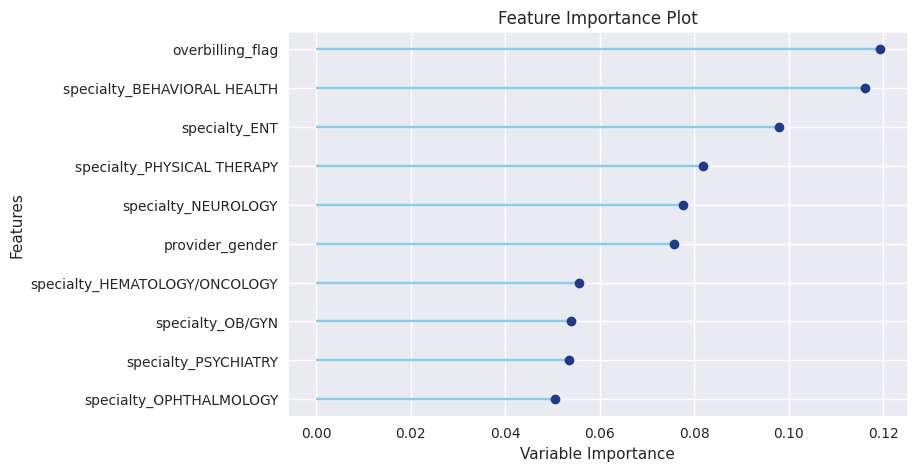

In [ ]:
# ==============================================================================
# --- CELL 5B.5 | FEATURE IMPORTANCE —WHICH FEATURES DRIVE PREDICTIONS? ---
# plot_model(model, plot='feature') shows which input features contributed most.
# Higher importance = more influence on the model's fraud predictions.
# We expect billed_to_allowed_ratio to rank highly based on Phase 2-3 findings.
# ==============================================================================

clf.plot_model(xgb_model, plot='feature')

In [ ]:
# ==============================================================================
# --- CELL 5B.6 | EVALUATE MODEL — FULL PERFORMANCE DASHBOARD ---
# evaluate_model() opens an interactive dashboard with:
#   - Confusion Matrix: shows true positives, false positives, etc.
#   - ROC Curve: plots true positive rate vs. false positive rate at each threshold
#   - Precision-Recall Curve: shows the precision/recall tradeoff
# ==============================================================================
clf.evaluate_model(xgb_model)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [ ]:
# ==============================================================================
# --- CELL 5B.7 | PRECISION vs. RECALL TRADEOFF DISCUSSION ---
#
# Precision = Of all claims we FLAG as fraud, what % actually ARE fraud?
#             High precision → fewer wasted investigations (fewer false alarms)
#
# Recall    = Of all ACTUAL fraud claims in the data, what % did we catch?
#             High recall → fewer missed fraud cases (fewer fraudulent payouts)
#
# These two metrics trade off against each other.
# For healthcare fraud detection, HIGH RECALL is the business priority because:
#   - The cost of MISSING a fraudulent claim (paying it out) is much larger
#     than the cost of INVESTIGATING a legitimate claim incorrectly.
#   - A missed fraud claim costs the company $hundreds to $thousands.
#   - An unnecessary investigation costs investigator time but is recoverable.
# Therefore: optimize for recall, even if it means more false alarms.
# ==============================================================================

print("""
PRECISION vs. RECALL TRADEOFF SUMMARY
======================================
Precision: How many of our fraud flags are actually fraud?
Recall:    How many actual frauds did we catch?

For healthcare claims fraud:
  → Prefer HIGH RECALL
  → Business would rather investigate 10 legitimate claims
    than miss 1 real fraudulent claim worth $5,000.
""")



PRECISION vs. RECALL TRADEOFF SUMMARY
Precision: How many of our fraud flags are actually fraud?
Recall:    How many actual frauds did we catch?

For healthcare claims fraud:
  → Prefer HIGH RECALL
  → Business would rather investigate 10 legitimate claims
    than miss 1 real fraudulent claim worth $5,000.



In [ ]:
# ==============================================================================
# --- CELL 5B.8 | FINALIZE AND SAVE MODEL ---
# finalize_model() retrains the model on the ENTIRE dataset (train + test).
# This uses all available data for maximum predictive power before deployment.
# save_model() writes the model to disk so we can load it in the Gradio interface.
# ==============================================================================

xgb_final = clf.finalize_model(xgb_model)
clf.save_model(xgb_final, '/content/drive/MyDrive/Colab Notebooks/fraud_xgb_model')
print("Model saved to Google Drive.")

Transformation Pipeline and Model Successfully Saved
Model saved to Google Drive.


# ==============================================================================
#
# MARKDOWN CELL:
#
# # Phase 6A: Business Recommendations
#
# Based on the full analysis, here is what we recommend to the insurance company.
#
# ## What to Automatically Flag for Review
# Flag any claim meeting **two or more** of the following criteria:
# - `billed_to_allowed_ratio` > 2.0 (billing more than twice the allowed amount)
# - Specialty falls in the **top high-fraud specialties** identified in Phase 2
# - Patient age falls in the **highest-fraud age group** identified in Phase 3
# - Model fraud probability > 30% (threshold tuned to prioritize recall)
#
# ## Specialty + Age + Billing Combinations Triggering Immediate Investigation
# The heatmap in Phase 4 identified specific specialty × age group combinations
# with fraud rates several times above the 4.47% baseline. These combinations
# should bypass the normal queue and go directly to a senior investigator.
#
# ## Prioritizing Limited Investigation Resources
# Rank all flagged claims by the model's fraud probability score, highest first.
# Investigators work through the list top-to-bottom. This ensures the most
# suspicious claims are always reviewed first, regardless of volume.
#
# ## Core Insight About How Fraud Operates in This Dataset
# Fraud is concentrated in **specific specialties**, characterized by
# **systematic overbilling** (billed amounts far exceeding allowed amounts),
# and disproportionately involves **certain patient age groups**.
# The `billed_to_allowed_ratio` is the most powerful predictive signal —
# suggesting fraudulent providers knowingly bill at multiples of the allowed rate.
#

#Based on the full analysis, the insurance company should implement a multi-layered review strategy anchored by the trained model. Any incoming claim should be automatically flagged for review if it meets two or more of the following criteria: a billed_to_allowed_ratio above 2.0, a specialty in the top high-fraud group identified in Phase 2, a patient age in the highest-fraud age bins (0–17 or 76+), or a model-assigned fraud probability above 30%. Certain specialty + age + billing pattern combinations identified in the Phase 4 heatmap — particularly high-fraud specialties paired with pediatric or elderly patients and above-average billing ratios — should trigger immediate escalation to a senior investigator, bypassing the standard review queue entirely. When investigation resources are limited, flagged claims should be ranked and worked in descending order of the model's fraud probability score, ensuring that the most suspicious cases are always reviewed first regardless of total volume. The core insight from this dataset is that fraud is not random: it is concentrated in specific specialties, driven by systematic overbilling (providers deliberately billing at multiples of the allowed rate), and disproportionately associated with certain patient age groups. The billed_to_allowed_ratio is the single strongest predictive signal and should be the primary trigger for any rule-based flagging system operating alongside the model.
# ==============================================================================


# ==============================================================================
#
# MARKDOWN CELL:
#
# # Phase 6B: Fraud Detection Interface (Gradio)
#
# We build an interactive tool that any auditor can use — no coding required.
# The auditor enters claim details and receives:
# - A fraud probability from the trained XGBoost model
# - A color-coded risk level (HIGH / MEDIUM / LOW)
# - The top reasons driving the risk assessment
#
# ==============================================================================



In [ ]:
# ==============================================================================
# --- CELL 6B.1 | INSTALL AND IMPORT GRADIO ---
# Gradio builds web interfaces inside Colab notebooks.
# gr.Interface() defines inputs, outputs, and the function that connects them.
# ==============================================================================

!pip install gradio
import gradio as gr


In [ ]:
# ==============================================================================
# --- CELL 6B.2 | LOAD THE SAVED MODEL AND REFERENCE DATA ---
# We reload the finalized XGBoost model from Google Drive.
# We also need:
#   - The list of specialties (for the dropdown menu)
#   - The median drive_distance (to fill in what the interface doesn't ask for)
# ==============================================================================

loaded_model = clf.load_model('/content/drive/MyDrive/Colab Notebooks/fraud_xgb_model')

specialty_list        = sorted(df['specialty'].dropna().unique().tolist())
median_drive_distance = df['drive_distance'].median()

print("Model loaded.")
print(f"Specialties available: {len(specialty_list)}")
print(f"Default drive distance (median): {median_drive_distance:.1f} miles")



Transformation Pipeline and Model Successfully Loaded
Model loaded.
Specialties available: 17
Default drive distance (median): 2.0 miles


In [ ]:
# ==============================================================================
# --- CELL 6B.3 | PREDICTION FUNCTION ---
# This function runs every time an auditor clicks "Submit" in the interface.
#
# Steps:
# 1. Compute the same engineered features the model was trained on
# 2. Build an input DataFrame with the exact same column names/order
# 3. Run clf.predict_model() to get the fraud probability
# 4. Classify into HIGH / MEDIUM / LOW risk
# 5. Generate plain-English reasons explaining the risk
#
# drive_distance is not collected from the interface (not required by assignment).
# We default it to the dataset median — a reasonable neutral assumption.
# process_month and process_quarter default to the current date.
# ==============================================================================# Recompute locally so this cell doesn't depend on Phase 4 running first
top_fraud_specialties = (
    df.groupby('specialty')['isFraud'].mean()
      .sort_values(ascending=False).head(3).index.tolist()
)

def predict_fraud(specialty, billed_amount, allowed_amount, member_age, provider_gender):
    try:
        billed_amount  = float(billed_amount or 0)
        allowed_amount = float(allowed_amount or 0)
        member_age     = float(member_age or 0)

        ratio = billed_amount / allowed_amount if allowed_amount else 0.0
        overbilling_amount = billed_amount - allowed_amount
        overbilling_flag   = int(billed_amount > allowed_amount)

        from datetime import datetime
        now = datetime.now()

        input_df = pd.DataFrame({
            'specialty':               [specialty],
            'billed_amount':           [billed_amount],
            'allowed_amount':          [allowed_amount],
            'drive_distance':          [float(median_drive_distance)],
            'provider_gender':         [provider_gender],
            'member_age':              [member_age],
            'billed_to_allowed_ratio': [ratio],
            'overbilling_amount':      [overbilling_amount],
            'overbilling_flag':        [overbilling_flag],
            'process_month':           [now.month],
            'process_quarter':         [(now.month - 1) // 3 + 1],
        })

        prediction = clf.predict_model(loaded_model, data=input_df, raw_score=True)

        # Explicitly grab the class-1 probability
        if 'prediction_score_1' in prediction.columns:
            fraud_prob = float(prediction['prediction_score_1'].iloc[0])
        elif 'prediction_score' in prediction.columns:
            # older PyCaret: prediction_score is the score of the predicted label
            label = int(prediction['prediction_label'].iloc[0])
            s = float(prediction['prediction_score'].iloc[0])
            fraud_prob = s if label == 1 else 1 - s
        else:
            return "Error", "Error", f"Unexpected columns: {list(prediction.columns)}"

        fraud_prob = max(0.0, min(1.0, fraud_prob))

        if   fraud_prob >= 0.50: risk_level = "HIGH RISK"
        elif fraud_prob >= 0.20: risk_level = "MEDIUM RISK"
        else:                    risk_level = "LOW RISK"

        reasons = []
        if ratio >= 3.0:
            reasons.append(f"Billed {ratio:.1f}x the allowed amount (${billed_amount:,.0f} vs ${allowed_amount:,.0f})")
        elif ratio >= 1.5:
            reasons.append(f"Billed ${overbilling_amount:,.0f} over allowed (ratio {ratio:.2f}x)")
        if specialty in top_fraud_specialties:
            reasons.append(f"High-fraud specialty: {specialty}")
        if member_age <= 17:
            reasons.append(f"Pediatric patient (age {int(member_age)})")
        elif member_age >= 76:
            reasons.append(f"Elderly patient (age {int(member_age)})")
        if overbilling_flag == 1 and ratio < 1.5:
            reasons.append(f"Billed (${billed_amount:,.0f}) exceeds allowed (${allowed_amount:,.0f})")
        if not reasons:
            reasons.append("No single dominant red flag — combined profile drives risk")

        return (
            f"{fraud_prob:.1%}",
            risk_level,
            "Factors driving this assessment:\n" + "\n".join(f"  • {r}" for r in reasons),
        )

    except Exception as e:
        import traceback
        return "Error", "Error", f"{type(e).__name__}: {e}\n\n{traceback.format_exc()}"



In [ ]:
# ==============================================================================
# --- CELL 6B.4 | BUILD AND LAUNCH THE GRADIO INTERFACE ---
# gr.Interface() wires up:
#   fn       = the Python function to call when the user submits
#   inputs   = the input widgets (Dropdown, Number, etc.)
#   outputs  = the output widgets (Textbox)
#
# interface.launch(share=True) creates a public URL that works outside of Colab.
# An auditor with no coding background can open the link and use the tool.
# ==============================================================================

interface = gr.Interface(
    fn = predict_fraud,

    inputs = [
        gr.Dropdown(
            choices = specialty_list,
            label   = "Medical Specialty",
            info    = "Select the treating provider's specialty"
        ),
        gr.Number(
            label = "Billed Amount ($)",
            value = 500.0,
            info  = "Total dollar amount the provider billed"
        ),
        gr.Number(
            label = "Allowed Amount ($)",
            value = 400.0,
            info  = "Maximum amount the insurance plan allows for this service"
        ),
        gr.Number(
            label = "Member Age",
            value = 45.0,
            info  = "Age of the patient"
        ),
        gr.Dropdown(
            choices = ['M', 'F'],
            label   = "Provider Gender",
            info    = "Gender of the treating provider"
        )
    ],

    outputs = [
        gr.Textbox(label="Fraud Probability"),
        gr.Textbox(label="Risk Level  (HIGH / MEDIUM / LOW)"),
        gr.Textbox(label="Top Reasons for Risk Assessment", lines=6)
    ],

    title       = "Healthcare Claims Fraud Detection Tool",
    description = (
        "Enter the details of an incoming claim to receive an instant fraud risk "
        "assessment powered by a trained XGBoost model. "
        "HIGH = probability ≥ 50%  |  MEDIUM = 20–50%  |  LOW = < 20%"
    )
)

# launch(share=True) generates a public URL — share it with your instructor
interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://101d2fb0ffea694ae0.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
